In [1]:
import pandas as pd

In [2]:
OzOFF_database_path="lipid_database/OzOFF_database/Database_OzOFF.parquet"
OzON_database_path = "lipid_database/OzON_databases/OzON_Possible_Database_0.parquet"
df_OFF = pd.read_parquet(OzOFF_database_path)
df_ON = pd.read_parquet(OzON_database_path)
df_OFF

,Lipid,Parent_Ion,Product_Ion,Class,Chain_length
0,FA(d2-16:0),425.4,183,FA,16
1,FA(5:0),269.3,183,FA,5
2,FA(5:1),267.3,183,FA,5
3,FA(5:2),265.3,183,FA,5
4,FA(5:3),263.3,183,FA,5
...,...,...,...,...,...
153,FA(30:1),617.3,183,FA,30
154,FA(30:2),615.3,183,FA,30
155,FA(30:3),613.3,183,FA,30
156,FA(30:4),611.3,183,FA,30


In [3]:
df_ON

,Lipid,Parent_Ion,Product_Ion,Species,Class,DB Location,FA mass,[FA+AMP]+
0,FA(5:0),269.3,183.0,5:0,FA,None,102.2,281.3
1,FA(6:0),283.3,183.0,6:0,FA,None,116.2,295.3
2,FA(6:1)_<>_n-2,269.2,183.0,6:1,FA,<>,114.1,281.2
3,FA(6:1)_<>_n-3,255.2,183.0,6:1,FA,<>,114.1,281.2
4,FA(6:1)_<>_n-4,241.2,183.0,6:1,FA,<>,114.1,281.2
...,...,...,...,...,...,...,...,...
6531,FA(30:6)_<BBFFF>_n-26,265.5,183.0,30:6,FA,<BBFFF>,440.4,607.5
6532,FA(30:6)_<FFFFF>_n-27,255.5,183.0,30:6,FA,<FFFFF>,440.4,607.5
6533,FA(30:6)_<BFFFF>_n-27,253.5,183.0,30:6,FA,<BFFFF>,440.4,607.5
6534,FA(30:6)_<FFFFF>_n-28,241.5,183.0,30:6,FA,<FFFFF>,440.4,607.5


# OFF 

# 1 - mzml parser

In [5]:
# Submit the SLURM job for mzml_parser_1.sh
!sbatch core/backend/mzml_parser_1_AMP_OFF.sh


Submitted batch job 19982060


In [6]:
df = pd.read_parquet('Projects/AMP/mzml_parsed/OFF/df_mzml_parser_1_OFF.parquet')
df

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition
0,None,227.1,183.0,0.011583,40.920002,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
1,None,227.1,183.0,0.024483,40.820004,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
2,None,227.1,183.0,0.037383,40.760002,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
3,None,227.1,183.0,0.050317,40.740002,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
4,None,227.1,183.0,0.063233,40.740002,11162023_Blank-AMP_2x_MRMs_O3off_01,227.1 -> 183.0
...,...,...,...,...,...,...,...
4796605,None,533.5,183.0,29.949033,42.920002,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
4796606,None,533.5,183.0,29.961967,43.360004,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
4796607,None,533.5,183.0,29.974883,50.240002,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0
4796608,None,533.5,183.0,29.987800,41.440002,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...,533.5 -> 183.0


In [7]:
transitions = pd.read_parquet('Projects/AMP/mzml_parsed/OFF/df_transition_summed_1_OFF.parquet')
transitions

,Parent_Ion,Product_Ion,Intensity,Transition,Sample_ID
0,227.1,183.0,141907.550026,227.1 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
1,241.1,183.0,101898.667385,241.1 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
2,255.2,183.0,191667.253429,255.2 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
3,269.1,183.0,174145.792530,269.1 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
4,283.2,183.0,684325.971741,283.2 -> 183.0,11162023_Blank-AMP_2x_MRMs_O3off_01
...,...,...,...,...,...
2250,507.4,183.0,625977.444618,507.4 -> 183.0,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...
2251,521.4,183.0,173889.252361,521.4 -> 183.0,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...
2252,533.4,183.0,135267.409386,533.4 -> 183.0,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...
2253,535.4,183.0,224620.855759,535.4 -> 183.0,11192023_5xFAD-m2-hippo-FAD257_AMP_2x_0.05uMd2...


# 2 - sample name 

In [8]:
# Submit the SLURM job for !sbatch core/backend/sample_2.sh
!sbatch core/backend/sample_2_AMP_OFF.sh


Submitted batch job 19982077


In [10]:

df = pd.read_parquet('Projects/AMP/samples/OFF/df_sample_2_hippo_5xFAD_m1_FAD231.parquet')
df

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_OFF
0,None,227.1,183.0,0.011583,41.320004,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
1,None,227.1,183.0,0.024483,41.440002,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
2,None,227.1,183.0,0.037383,41.380001,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
3,None,227.1,183.0,0.050317,41.360004,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
4,None,227.1,183.0,0.063233,41.380001,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
...,...,...,...,...,...,...,...,...,...,...
127706,None,533.5,183.0,29.949017,42.580002,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
127707,None,533.5,183.0,29.961950,42.660004,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
127708,None,533.5,183.0,29.974867,40.940002,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767
127709,None,533.5,183.0,29.987783,41.240002,11192023_5xFAD-m1-hippo-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,hippo_5xFAD_m1_FAD231,None,7.899767


# 3 - Match lipids NOT POSSIBLE

count # of files and set this number in the .sh file

In [7]:
input_dir = 'Projects/AMP/samples/OFF/'
import glob; num_files = len(glob.glob('Projects/AMP/samples/OFF/*.parquet'))
num_files   


47

In [12]:
# Submit the SLURM job for !sbatch core/backend/match_3.sh
!sbatch core/backend/not_possible/match_3_AMP_OFF_notpossible.sh



Submitted batch job 20159639


In [13]:
import pandas as pd
df = pd.read_parquet('Projects/AMP/match/OFF/notpossible/df_match_3_cereb_5xFAD_m1_FAD231.parquet')
print(df['Lipid'].dtype)
print(df['Lipid'].unique())

df

object
[''
 'FA(6:1)_<>_n-4 | FA(6:2)_<F>_n-4 | FA(6:3)_<FF>_n-4 | FA(6:4)_<FFF>_n-4 | FA(7:1)_<>_n-5 | FA(7:2)_<F>_n-5 | FA(7:3)_<FF>_n-5 | FA(7:4)_<FFF>_n-5 | FA(7:5)_<FFFF>_n-5 | FA(8:1)_<>_n-6 | FA(8:2)_<F>_n-6 | FA(8:3)_<FF>_n-6 | FA(8:4)_<FFF>_n-6 | FA(8:5)_<FFFF>_n-6 | FA(8:6)_<FFFFF>_n-6 | FA(9:1)_<>_n-7 | FA(9:2)_<F>_n-7 | FA(9:3)_<FF>_n-7 | FA(9:4)_<FFF>_n-7 | FA(9:5)_<FFFF>_n-7 | FA(9:6)_<FFFFF>_n-7 | FA(10:1)_<>_n-8 | FA(10:2)_<F>_n-8 | FA(10:3)_<FF>_n-8 | FA(10:4)_<FFF>_n-8 | FA(10:5)_<FFFF>_n-8 | FA(10:6)_<FFFFF>_n-8 | FA(11:1)_<>_n-9 | FA(11:2)_<F>_n-9 | FA(11:3)_<FF>_n-9 | FA(11:4)_<FFF>_n-9 | FA(11:5)_<FFFF>_n-9 | FA(11:6)_<FFFFF>_n-9 | FA(12:1)_<>_n-10 | FA(12:2)_<F>_n-10 | FA(12:3)_<FF>_n-10 | FA(12:4)_<FFF>_n-10 | FA(12:5)_<FFFF>_n-10 | FA(12:6)_<FFFFF>_n-10 | FA(13:1)_<>_n-11 | FA(13:2)_<F>_n-11 | FA(13:3)_<FF>_n-11 | FA(13:4)_<FFF>_n-11 | FA(13:5)_<FFFF>_n-11 | FA(13:6)_<FFFFF>_n-11 | FA(14:1)_<>_n-12 | FA(14:2)_<F>_n-12 | FA(14:3)_<FF>_n-12 | FA(14:4)_<FFF>_n-12 

,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_OFF,Class
0,,227.1,183.0,0.011583,42.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,
1,,227.1,183.0,0.024483,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,
2,,227.1,183.0,0.037383,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,
3,,227.1,183.0,0.050317,42.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,
4,,227.1,183.0,0.063233,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,
...,...,...,...,...,...,...,...,...,...,...,...
127706,FA(25:2)_<B>_n-2 | FA(25:3)_<BF>_n-2 | FA(26:2...,533.5,183.0,29.949050,43.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...
127707,FA(25:2)_<B>_n-2 | FA(25:3)_<BF>_n-2 | FA(26:2...,533.5,183.0,29.961983,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...
127708,FA(25:2)_<B>_n-2 | FA(25:3)_<BF>_n-2 | FA(26:2...,533.5,183.0,29.974900,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...
127709,FA(25:2)_<B>_n-2 | FA(25:3)_<BF>_n-2 | FA(26:2...,533.5,183.0,29.987817,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,533.5 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...


# 4 - group

In [20]:
!sbatch core/backend/not_possible/group_4_AMP_OFF_notpossible.sh

Submitted batch job 20160085


In [21]:
import pandas as pd

# Load the parquet file
df = pd.read_parquet('Projects/AMP/group/OFF/notpossible/df_group_4_cereb_5xFAD_m1_FAD231_OFF.parquet')

# # Filter out the rows where Lipid is 'FA(24:1)' and Parent_Ion is 533.5
# filtered_df = df[~((df['Lipid'] == 'FA(24:1)') & (df['Parent_Ion'] == 533.5))]

# # # Save the filtered DataFrame
# # filtered_df.to_parquet('Projects/STD/group/OFF/df_group_4_FAME_OFF_filtered24.parquet')

# # Display the filtered DataFrame
# filtered_df
df


,Lipid,Parent_Ion,Product_Ion,Retention_Time,OzESI_Intensity,Sample_ID,Transition,Sample,STD,STD_RT_OFF,Class,Species,Biology,Genotype,Cage,Mouse,group_by_ion,group_by_lipid
0,,495.4,183.0,0.001967,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,495.4 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,,Unknown_1,cereb,5xFAD,FAD231,m1,47,0
1,,227.1,183.0,0.011583,42.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,,Unknown_1,cereb,5xFAD,FAD231,m1,0,0
2,,495.4,183.0,0.014883,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,495.4 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,,Unknown_1,cereb,5xFAD,FAD231,m1,47,0
3,,227.1,183.0,0.024483,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,227.1 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,,Unknown_1,cereb,5xFAD,FAD231,m1,0,0
4,,495.4,183.0,0.027783,45.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,495.4 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,,Unknown_1,cereb,5xFAD,FAD231,m1,47,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127706,FA(d2-16:0),425.4,183.0,29.941917,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,425.4 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,FA,16:0,cereb,5xFAD,FAD231,m1,30,52
127707,FA(d2-16:0),425.4,183.0,29.954850,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,425.4 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,FA,16:0,cereb,5xFAD,FAD231,m1,30,52
127708,FA(d2-16:0),425.4,183.0,29.967767,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,425.4 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,FA,16:0,cereb,5xFAD,FAD231,m1,30,52
127709,FA(d2-16:0),425.4,183.0,29.980683,41.0,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,425.4 -> 183.0,cereb_5xFAD_m1_FAD231,None,8.016083,FA,16:0,cereb,5xFAD,FAD231,m1,30,52


In [22]:
# Assuming df is your DataFrame
for index, row in df[['Lipid', 'group_by_lipid']].drop_duplicates().iterrows():
    print(f"Lipid: {row['Lipid']}, group_by_lipid: {row['group_by_lipid']}")


Lipid: , group_by_lipid: 0
Lipid: FA(10:0) | FA(11:1)_<>_n-2 | FA(11:2)_<F>_n-2 | FA(12:1)_<>_n-3 | FA(12:2)_<F>_n-3 | FA(12:3)_<FF>_n-3 | FA(13:1)_<>_n-4 | FA(13:2)_<F>_n-4 | FA(13:3)_<FF>_n-4 | FA(13:4)_<FFF>_n-4 | FA(14:1)_<>_n-5 | FA(14:2)_<F>_n-5 | FA(14:3)_<FF>_n-5 | FA(14:4)_<FFF>_n-5 | FA(14:5)_<FFFF>_n-5 | FA(15:1)_<>_n-6 | FA(15:2)_<F>_n-6 | FA(15:3)_<FF>_n-6 | FA(15:4)_<FFF>_n-6 | FA(15:5)_<FFFF>_n-6 | FA(15:6)_<FFFFF>_n-6 | FA(16:1)_<>_n-7 | FA(16:2)_<F>_n-7 | FA(16:3)_<FF>_n-7 | FA(16:4)_<FFF>_n-7 | FA(16:5)_<FFFF>_n-7 | FA(16:6)_<FFFFF>_n-7 | FA(17:1)_<>_n-8 | FA(17:2)_<F>_n-8 | FA(17:3)_<FF>_n-8 | FA(17:4)_<FFF>_n-8 | FA(17:5)_<FFFF>_n-8 | FA(17:6)_<FFFFF>_n-8 | FA(18:1)_<>_n-9 | FA(18:2)_<F>_n-9 | FA(18:3)_<FF>_n-9 | FA(18:4)_<FFF>_n-9 | FA(18:5)_<FFFF>_n-9 | FA(18:6)_<FFFFF>_n-9 | FA(19:1)_<>_n-10 | FA(19:2)_<F>_n-10 | FA(19:3)_<FF>_n-10 | FA(19:4)_<FFF>_n-10 | FA(19:5)_<FFFF>_n-10 | FA(19:6)_<FFFFF>_n-10 | FA(20:1)_<>_n-11 | FA(20:2)_<F>_n-11 | FA(20:3)_<FF>_n-11 | FA

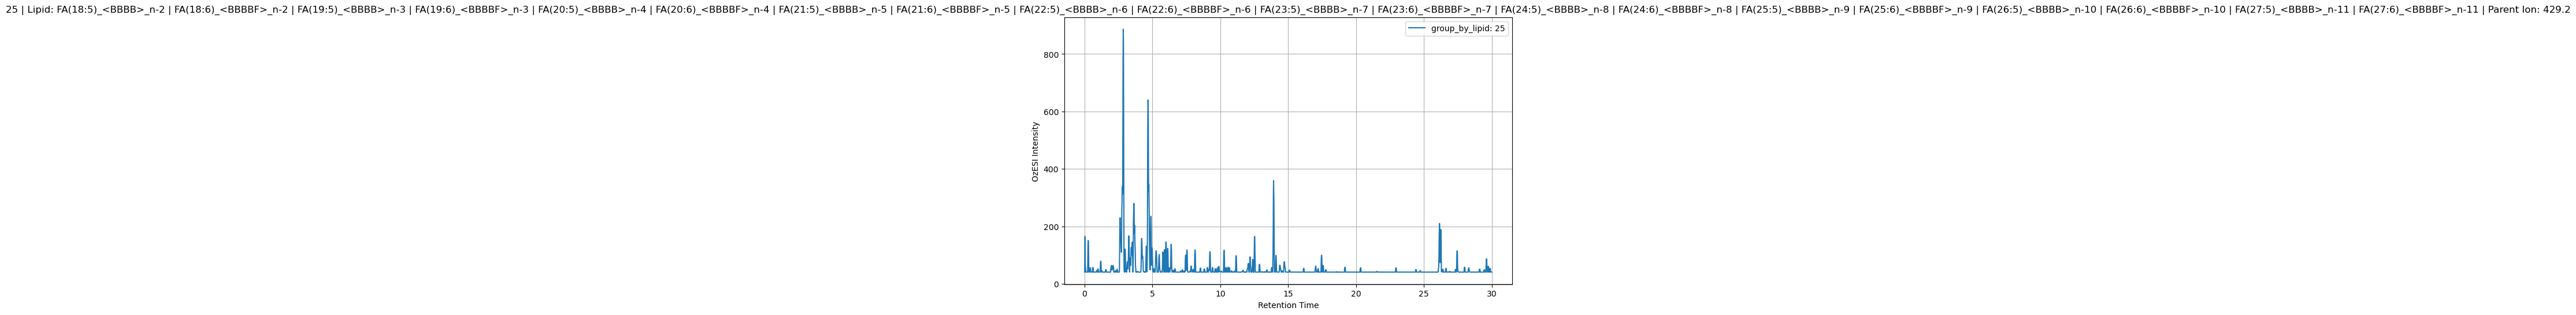

In [23]:
import matplotlib.pyplot as plt

# Function to plot chromatograms, with options to either display or save the plots
def plot_chromatograms(df, save_path=None, show_only=False, specific_group=None):
    if specific_group:
        # If a specific group is provided, filter the DataFrame for that group only
        group_data = df[df['group_by_lipid'] == specific_group]
        
        # Ensure the Retention_Time is sorted
        group_data = group_data.sort_values(by='Retention_Time')
        
        # Extract Lipid and Parent Ion values from the first row of the group
        lipid = group_data['Lipid'].iloc[0] if not group_data.empty else f"Unknown_Lipid_{specific_group}"
        parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
        
        plt.figure(figsize=(10, 6))
        plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'group_by_lipid: {specific_group}')
        plt.xlabel('Retention Time')
        plt.ylabel('OzESI Intensity')
        
        # Add Lipid and Parent Ion to the title
        plt.title(f'{specific_group} | Lipid: {lipid} | Parent Ion: {parent_ion}')
        
        plt.legend()
        plt.grid(True)
        
        if show_only:
            plt.show()  # Display the plot
        else:
            # Save the plot as a PNG with the lipid name followed by "_OFF"
            save_file = f"{save_path}/{lipid.replace(':', '_').replace('/', '_')}_OFF.png"  # Clean filename
            plt.savefig(save_file)
            print(f"Plot saved as {save_file}")
        plt.close()  # Close the figure after displaying or saving

    else:
        # Iterate through each unique group_by_lipid value if no specific group is provided
        for group_value in df['group_by_lipid'].unique():
            group_data = df[df['group_by_lipid'] == group_value]
            
            # Ensure the Retention_Time is sorted
            group_data = group_data.sort_values(by='Retention_Time')
            
            # Extract Lipid and Parent Ion values from the first row of the group
            lipid = group_data['Lipid'].iloc[0] if not group_data.empty else f"Unknown_Lipid_{group_value}"
            parent_ion = group_data['Parent_Ion'].iloc[0] if not group_data.empty else "Unknown Parent Ion"
            
            plt.figure(figsize=(10, 6))
            plt.plot(group_data['Retention_Time'], group_data['OzESI_Intensity'], label=f'group_by_lipid: {group_value}')
            plt.xlabel('Retention Time')
            plt.ylabel('OzESI Intensity')
            
            # Add Lipid and Parent Ion to the title
            plt.title(f'{group_value} | Lipid: {lipid} | Parent Ion: {parent_ion}')
            
            plt.legend()
            plt.grid(True)
            
            if show_only:
                plt.show()  # Display the plot
                break  # Exit after showing one plot if in "show only" mode
            else:
                # Save the plot as a PNG with the lipid name followed by "_OFF"
                save_file = f"{save_path}/{lipid.replace(':', '_').replace('/', '_')}_OFF.png"  # Clean filename
                plt.savefig(save_file)
                print(f"Plot saved as {save_file}")
            plt.close()  # Close the figure to avoid overlap in the next iteration

# Example usage:
# User-defined variable for the save path
save_path = 'Projects/AMP/plots/OFF_plots/'  # Replace with your desired save path

# # Call the function to either display or save chromatograms
# # For saving and iterating through all groups:
# plot_chromatograms(df, save_path=save_path)

# For showing only a specific group without saving:
plot_chromatograms(df, show_only=True, specific_group=25)


# 5 - Analysis

In [25]:
!sbatch core/backend/not_possible/analysis_5_AMP_OFF_notpossible.sh

Submitted batch job 20160172


In [26]:
# import pandas as pd
# df = pd.read_parquet('Projects/STD/analysis/OFF/multiple_values/df_analysis_5_FAME_OFF.parquet')
#  #Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF.parquet
# print(df['Lipid'].unique())
# df.head(10)
import pandas as pd
df = pd.read_parquet('Projects/AMP/analysis/OFF/notpossible/df_analysis_5_cereb_5xFAD_m1_FAD231_OFF.parquet')
df

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column
0,FA(5:0) | FA(6:1)_<>_n-2 | FA(6:2)_<F>_n-2 | F...,2.646717,13160.0,3,44,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,269.1 -> 183.0,cereb_5xFAD_m1_FAD231,269.1,183.0,5:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,13160.0,0.089117,0.090433,1190.102667,group_by_lipid
1,FA(6:0) | FA(7:1)_<>_n-2 | FA(7:2)_<F>_n-2 | F...,0.630917,13596.0,4,45,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,283.2 -> 183.0,cereb_5xFAD_m1_FAD231,283.2,183.0,6:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,13596.0,0.060201,0.064600,878.301600,group_by_lipid
2,FA(6:0) | FA(7:1)_<>_n-2 | FA(7:2)_<F>_n-2 | F...,2.039250,1510.0,4,45,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,283.2 -> 183.0,cereb_5xFAD_m1_FAD231,283.2,183.0,6:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1510.0,0.045624,0.051683,78.041833,group_by_lipid
3,FA(6:0) | FA(7:1)_<>_n-2 | FA(7:2)_<F>_n-2 | F...,2.142617,1809.0,4,45,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,283.2 -> 183.0,cereb_5xFAD_m1_FAD231,283.2,183.0,6:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1809.0,0.047668,0.051683,93.495150,group_by_lipid
4,FA(6:0) | FA(7:1)_<>_n-2 | FA(7:2)_<F>_n-2 | F...,2.271817,3689.0,4,45,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,283.2 -> 183.0,cereb_5xFAD_m1_FAD231,283.2,183.0,6:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,3689.0,0.138223,0.142117,524.268383,group_by_lipid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,FA(22:0) | FA(23:1)_<>_n-2 | FA(23:2)_<F>_n-2 ...,13.968217,2183.0,50,38,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,507.4 -> 183.0,cereb_5xFAD_m1_FAD231,507.4,183.0,22:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,2183.0,0.159521,0.167950,366.634850,group_by_lipid
318,FA(22:0) | FA(23:1)_<>_n-2 | FA(23:2)_<F>_n-2 ...,14.162033,1260.0,50,38,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,507.4 -> 183.0,cereb_5xFAD_m1_FAD231,507.4,183.0,22:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1260.0,0.060748,0.051667,65.100000,group_by_lipid
319,FA(22:0) | FA(23:1)_<>_n-2 | FA(23:2)_<F>_n-2 ...,14.265400,1028.0,50,38,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,507.4 -> 183.0,cereb_5xFAD_m1_FAD231,507.4,183.0,22:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1028.0,0.053343,0.051683,53.130467,group_by_lipid
320,FA(23:2)_<B>_n-2 | FA(23:3)_<BF>_n-2 | FA(24:2...,12.392150,1559.0,49,40,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,505.4 -> 183.0,cereb_5xFAD_m1_FAD231,505.4,183.0,23:2,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1559.0,0.178843,0.180883,281.997117,group_by_lipid


In [30]:
notpossible_lipids = df[df['Lipid'].str.contains('18:1', case=False, na=False)]
sorted_notpossible_lipids = notpossible_lipids.sort_values(by='OzESI_Intensity', ascending=False)
#print unique Lipid values
print(sorted_notpossible_lipids['Lipid'].unique())
sorted_notpossible_lipids


['FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 | FA(18:1)_<>_n-3 | FA(18:2)_<F>_n-3 | FA(18:3)_<FF>_n-3 | FA(19:1)_<>_n-4 | FA(19:2)_<F>_n-4 | FA(19:3)_<FF>_n-4 | FA(19:4)_<FFF>_n-4 | FA(20:1)_<>_n-5 | FA(20:2)_<F>_n-5 | FA(20:3)_<FF>_n-5 | FA(20:4)_<FFF>_n-5 | FA(20:5)_<FFFF>_n-5 | FA(21:1)_<>_n-6 | FA(21:2)_<F>_n-6 | FA(21:3)_<FF>_n-6 | FA(21:4)_<FFF>_n-6 | FA(21:5)_<FFFF>_n-6 | FA(21:6)_<FFFFF>_n-6 | FA(22:1)_<>_n-7 | FA(22:2)_<F>_n-7 | FA(22:3)_<FF>_n-7 | FA(22:4)_<FFF>_n-7 | FA(22:5)_<FFFF>_n-7 | FA(22:6)_<FFFFF>_n-7 | FA(23:1)_<>_n-8 | FA(23:2)_<F>_n-8 | FA(23:3)_<FF>_n-8 | FA(23:4)_<FFF>_n-8 | FA(23:5)_<FFFF>_n-8 | FA(23:6)_<FFFFF>_n-8 | FA(24:1)_<>_n-9 | FA(24:2)_<F>_n-9 | FA(24:3)_<FF>_n-9 | FA(24:4)_<FFF>_n-9 | FA(24:5)_<FFFF>_n-9 | FA(24:6)_<FFFFF>_n-9 | FA(25:1)_<>_n-10 | FA(25:2)_<F>_n-10 | FA(25:3)_<FF>_n-10 | FA(25:4)_<FFF>_n-10 | FA(25:5)_<FFFF>_n-10 | FA(25:6)_<FFFFF>_n-10 | FA(26:1)_<>_n-11 | FA(26:2)_<F>_n-11 | FA(26:3)_<FF>_n-11 | FA(26:4)_<FFF>_n-11 | FA(26:5)_<FF

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column
109,FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 ...,8.042133,10614408.0,29,16,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,423.3 -> 183.0,cereb_5xFAD_m1_FAD231,423.3,183.0,16:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,10614408.0,0.140745,0.129200,1.371382e+06,group_by_lipid
73,FA(14:0) | FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 ...,6.299300,1530650.0,22,10,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,395.3 -> 183.0,cereb_5xFAD_m1_FAD231,395.3,183.0,14:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1530650.0,0.081688,0.090450,1.384473e+05,group_by_lipid
20,FA(9:0) | FA(10:1)_<>_n-2 | FA(10:2)_<F>_n-2 |...,3.834167,786682.0,9,50,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,325.2 -> 183.0,cereb_5xFAD_m1_FAD231,325.2,183.0,9:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,786682.0,0.059474,0.064600,5.081966e+04,group_by_lipid
56,FA(12:0) | FA(13:1)_<>_n-2 | FA(13:2)_<F>_n-2 ...,4.801767,436946.0,16,5,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,367.3 -> 183.0,cereb_5xFAD_m1_FAD231,367.3,183.0,12:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,436946.0,0.069926,0.064600,2.822671e+04,group_by_lipid
31,FA(10:0) | FA(11:1)_<>_n-2 | FA(11:2)_<F>_n-2 ...,4.053417,357538.0,11,1,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,339.3 -> 183.0,cereb_5xFAD_m1_FAD231,339.3,183.0,10:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,357538.0,0.060785,0.064600,2.309695e+04,group_by_lipid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,FA(9:0) | FA(10:1)_<>_n-2 | FA(10:2)_<F>_n-2 |...,7.413117,1018.0,9,50,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,325.2 -> 183.0,cereb_5xFAD_m1_FAD231,325.2,183.0,9:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1018.0,0.069415,0.064600,6.576280e+01,group_by_lipid
126,FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 ...,11.698583,1014.0,29,16,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,423.3 -> 183.0,cereb_5xFAD_m1_FAD231,423.3,183.0,16:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1014.0,0.029013,0.025850,2.621190e+01,group_by_lipid
150,FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 ...,18.856450,1010.0,29,16,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,423.3 -> 183.0,cereb_5xFAD_m1_FAD231,423.3,183.0,16:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1010.0,0.053876,0.064600,6.524600e+01,group_by_lipid
136,FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 ...,14.101767,1005.0,29,16,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,423.3 -> 183.0,cereb_5xFAD_m1_FAD231,423.3,183.0,16:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1005.0,0.068129,0.064617,6.493975e+01,group_by_lipid


# OzOFF notpossbile - Remove OzON not possible

In [28]:
ozon_test = pd.read_parquet('Projects/AMP/fame_filter_7/cereb_5xFAD_m1_FAD231_fame_filter_7.parquet')
ozon_test

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,STD_RT_ON,STD_RT_OFF,STD_RT_Dif,Biology,Genotype,Cage,Mouse,n_value,Adjusted_RT,Isomer
0,FA(10:1)_<>_n-3,3.421117,2503.0,6,1,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,311.3 -> 183.0,cereb_5xFAD_m1_FAD231,311.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,3,3.408200,1
1,FA(12:1)_<>_n-5,3.421117,2503.0,6,11,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,311.3 -> 183.0,cereb_5xFAD_m1_FAD231,311.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,5,3.408200,1
2,FA(13:1)_<>_n-5,3.627433,4018.0,8,21,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,325.2 -> 183.0,cereb_5xFAD_m1_FAD231,325.2,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,5,3.614517,1
3,FA(13:1)_<>_n-6,3.421117,2503.0,6,22,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,311.3 -> 183.0,cereb_5xFAD_m1_FAD231,311.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,6,3.408200,1
4,FA(16:1)_<>_n-3,6.984067,1081.0,21,55,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,395.3 -> 183.0,cereb_5xFAD_m1_FAD231,395.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,3,6.971150,2
5,FA(16:1)_<>_n-3,6.841950,1813.0,21,55,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,395.3 -> 183.0,cereb_5xFAD_m1_FAD231,395.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,3,6.829033,1
6,FA(16:1)_<>_n-7,6.947550,2850.0,10,59,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,339.3 -> 183.0,cereb_5xFAD_m1_FAD231,339.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,7,6.934633,1
7,FA(16:2)_<F>_n-2,3.972817,1902.0,25,74,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,409.3 -> 183.0,cereb_5xFAD_m1_FAD231,409.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,2,3.959900,1
8,FA(16:2)_<B>_n-2,3.895500,1249.0,24,62,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,407.3 -> 183.0,cereb_5xFAD_m1_FAD231,407.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,2,3.882583,1
9,FA(16:2)_<F>_n-7,3.911283,2576.0,10,79,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,339.3 -> 183.0,cereb_5xFAD_m1_FAD231,339.3,183.0,...,8.029,8.016083,-0.012917,cereb,5xFAD,FAD231,m1,7,3.898367,1


In [36]:
import pandas as pd

def match_lipids(sorted_notpossible_lipids, ozon_test):
    # Create a new column in the OFF data to store matched information
    sorted_notpossible_lipids['Matched_Lipid_ON'] = None

    # Iterate through each row in the ON data
    for index_on, row_on in ozon_test.iterrows():
        on_lipid = row_on['Lipid'].strip()  # Trim spaces for accurate matching
        match_found = False

        # Iterate through each row in the OFF data
        for index_off, row_off in sorted_notpossible_lipids.iterrows():
            # Split the OFF Lipid values by '|' and trim each part
            off_lipids = [lipid.strip() for lipid in row_off['Lipid'].split('|')]

            # Check if the ON lipid matches any of the possible OFF lipids
            if any(on_lipid.lower() == off_lipid.lower() for off_lipid in off_lipids):
                # If a match is found, update the 'Matched_Lipid_ON' column in the OFF DataFrame
                sorted_notpossible_lipids.at[index_off, 'Matched_Lipid_ON'] = on_lipid
                match_found = True
                break  # Stop searching for this ON lipid once a match is found

        # If no match is found, you can choose to log or handle this scenario
        if not match_found:
            print(f"No match found for ON lipid: {on_lipid}")

    # Filter the OFF data to only keep rows with matched Lipids
    matched_lipids = sorted_notpossible_lipids.dropna(subset=['Matched_Lipid_ON']).copy()

    return matched_lipids

# Example usage
# Assuming sorted_notpossible_lipids and ozon_test are the input DataFrames
matched_lipids_df = match_lipids(sorted_notpossible_lipids, ozon_test)

# Display or save the result
matched_lipids_df
# matched_lipids_df.to_csv('matched_lipids.csv', index=False)


No match found for ON lipid: FA(16:2)_<B>_n-2
No match found for ON lipid: FA(16:2)_<B>_n-7
No match found for ON lipid: FA(18:2)_<B>_n-6
No match found for ON lipid: FA(18:4)_<BFF>_n-4


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Matched_Lipid_ON
109,FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 ...,8.042133,10614408.0,29,16,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,423.3 -> 183.0,cereb_5xFAD_m1_FAD231,423.3,183.0,16:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,10614408.0,0.140745,0.12920,1.371382e+06,group_by_lipid,FA(18:1)_<>_n-3
73,FA(14:0) | FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 ...,6.299300,1530650.0,22,10,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,395.3 -> 183.0,cereb_5xFAD_m1_FAD231,395.3,183.0,14:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,1530650.0,0.081688,0.09045,1.384473e+05,group_by_lipid,FA(18:4)_<FFF>_n-5
20,FA(9:0) | FA(10:1)_<>_n-2 | FA(10:2)_<F>_n-2 |...,3.834167,786682.0,9,50,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,325.2 -> 183.0,cereb_5xFAD_m1_FAD231,325.2,183.0,9:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,786682.0,0.059474,0.06460,5.081966e+04,group_by_lipid,FA(18:1)_<>_n-10
56,FA(12:0) | FA(13:1)_<>_n-2 | FA(13:2)_<F>_n-2 ...,4.801767,436946.0,16,5,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,367.3 -> 183.0,cereb_5xFAD_m1_FAD231,367.3,183.0,12:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,436946.0,0.069926,0.06460,2.822671e+04,group_by_lipid,FA(18:1)_<>_n-7
31,FA(10:0) | FA(11:1)_<>_n-2 | FA(11:2)_<F>_n-2 ...,4.053417,357538.0,11,1,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,339.3 -> 183.0,cereb_5xFAD_m1_FAD231,339.3,183.0,10:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,357538.0,0.060785,0.06460,2.309695e+04,group_by_lipid,FA(18:1)_<>_n-9
89,FA(15:0) | FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 ...,7.202917,268332.0,26,13,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,409.3 -> 183.0,cereb_5xFAD_m1_FAD231,409.3,183.0,15:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,268332.0,0.089770,0.09045,2.427063e+04,group_by_lipid,FA(18:4)_<FFF>_n-4
15,FA(8:0) | FA(9:1)_<>_n-2 | FA(9:2)_<F>_n-2 | F...,3.602017,121091.0,7,49,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,311.3 -> 183.0,cereb_5xFAD_m1_FAD231,311.3,183.0,8:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,121091.0,0.059794,0.06460,7.822479e+03,group_by_lipid,FA(13:1)_<>_n-6
45,FA(11:0) | FA(12:1)_<>_n-2 | FA(12:2)_<F>_n-2 ...,4.350167,47381.0,13,3,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,353.3 -> 183.0,cereb_5xFAD_m1_FAD231,353.3,183.0,11:0,FA | FA | FA | FA | FA | FA | FA | FA | FA | F...,None,8.016083,47381.0,0.066419,0.06460,3.060813e+03,group_by_lipid,FA(18:1)_<>_n-8


In [44]:
import pandas as pd

def match_lipids_with_adjusted_rt_to_rt(ozon_test, sorted_notpossible_lipids, rt_window=0.5):
    # Create new columns in the ON data to store matched information from OFF
    ozon_test['Matched_Lipid_OFF'] = None
    ozon_test['Intensity_OFF'] = None
    ozon_test['Retention_Time_OFF'] = None

    # Iterate through each row in the ON data
    for index_on, row_on in ozon_test.iterrows():
        on_lipid = row_on['Lipid'].strip()  # Trim spaces for accurate matching
        on_adjusted_rt = row_on['Adjusted_RT']  # Adjusted RT of the ON lipid
        match_found = False

        # Iterate through each row in the OFF data
        for index_off, row_off in sorted_notpossible_lipids.iterrows():
            # Split the OFF Lipid values by '|' and trim each part
            off_lipids = [lipid.strip() for lipid in row_off['Lipid'].split('|')]
            off_retention_time = row_off['Retention_Time']  # Retention time of the OFF lipid

            # Check if the ON lipid matches any of the possible OFF lipids
            # and if the Adjusted_RT is within the specified window of the Retention_Time
            if any(on_lipid.lower() == off_lipid.lower() for off_lipid in off_lipids) and abs(on_adjusted_rt - off_retention_time) <= rt_window:
                # If a match is found, update the 'Matched_Lipid_OFF', 'Intensity_OFF', and 'Retention_Time_OFF' columns in the ON DataFrame
                ozon_test.at[index_on, 'Matched_Lipid_OFF'] = row_off['Lipid']
                ozon_test.at[index_on, 'Intensity_OFF'] = row_off['OzESI_Intensity']
                ozon_test.at[index_on, 'Retention_Time_OFF'] = off_retention_time
                match_found = True
                break  # Stop searching for this ON lipid once a match is found

        # If no match is found, you can choose to log or handle this scenario
        if not match_found:
            print(f"No match found for ON lipid: {on_lipid} within Adjusted_RT window {on_adjusted_rt} ± {rt_window}")

    # Filter the ON data to only keep rows with matched Lipids
    matched_lipids = ozon_test.dropna(subset=['Matched_Lipid_OFF']).copy()

    return matched_lipids

# Example usage
# Assuming sorted_notpossible_lipids and ozon_test are the input DataFrames
matched_lipids_df = match_lipids_with_adjusted_rt_to_rt(ozon_test, sorted_notpossible_lipids, rt_window=0.25)



#print values of Matched_Lipid_OFF in row 1
print(matched_lipids_df['Matched_Lipid_OFF'].iloc[1])
# Display or save the result
matched_lipids_df
# matched_lipids_df.to_csv('matched_lipids.csv', index=False)


No match found for ON lipid: FA(16:2)_<B>_n-2 within Adjusted_RT window 3.8825833333333346 ± 0.25
No match found for ON lipid: FA(16:2)_<B>_n-7 within Adjusted_RT window 3.833966666666668 ± 0.25
No match found for ON lipid: FA(18:1)_<>_n-7 within Adjusted_RT window 8.613283333333335 ± 0.25
No match found for ON lipid: FA(18:1)_<>_n-9 within Adjusted_RT window 8.653050000000002 ± 0.25
No match found for ON lipid: FA(18:1)_<>_n-10 within Adjusted_RT window 8.743900000000002 ± 0.25
No match found for ON lipid: FA(18:1)_<>_n-7 within Adjusted_RT window 8.897516666666668 ± 0.25
No match found for ON lipid: FA(18:1)_<>_n-8 within Adjusted_RT window 9.104866666666668 ± 0.25
No match found for ON lipid: FA(18:1)_<>_n-9 within Adjusted_RT window 8.963150000000002 ± 0.25
No match found for ON lipid: FA(18:1)_<>_n-10 within Adjusted_RT window 9.002316666666669 ± 0.25
No match found for ON lipid: FA(18:2)_<B>_n-6 within Adjusted_RT window 7.773033333333335 ± 0.25
No match found for ON lipid: FA(18

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,...,Genotype,Cage,Mouse,n_value,Adjusted_RT,Isomer,Matched_Lipid_OFF,Intensity_OFF,Retention_Time_OFF,Adjusted_RT_OFF
0,FA(10:1)_<>_n-3,3.421117,2503.0,6,1,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,311.3 -> 183.0,cereb_5xFAD_m1_FAD231,311.3,183.0,...,5xFAD,FAD231,m1,3,3.408200,1,FA(8:0) | FA(9:1)_<>_n-2 | FA(9:2)_<F>_n-2 | F...,121091.0,3.602017,None
1,FA(12:1)_<>_n-5,3.421117,2503.0,6,11,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,311.3 -> 183.0,cereb_5xFAD_m1_FAD231,311.3,183.0,...,5xFAD,FAD231,m1,5,3.408200,1,FA(8:0) | FA(9:1)_<>_n-2 | FA(9:2)_<F>_n-2 | F...,121091.0,3.602017,None
2,FA(13:1)_<>_n-5,3.627433,4018.0,8,21,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,325.2 -> 183.0,cereb_5xFAD_m1_FAD231,325.2,183.0,...,5xFAD,FAD231,m1,5,3.614517,1,FA(9:0) | FA(10:1)_<>_n-2 | FA(10:2)_<F>_n-2 |...,786682.0,3.834167,None
3,FA(13:1)_<>_n-6,3.421117,2503.0,6,22,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,311.3 -> 183.0,cereb_5xFAD_m1_FAD231,311.3,183.0,...,5xFAD,FAD231,m1,6,3.408200,1,FA(8:0) | FA(9:1)_<>_n-2 | FA(9:2)_<F>_n-2 | F...,121091.0,3.602017,None
4,FA(16:1)_<>_n-3,6.984067,1081.0,21,55,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,395.3 -> 183.0,cereb_5xFAD_m1_FAD231,395.3,183.0,...,5xFAD,FAD231,m1,3,6.971150,2,FA(14:0) | FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 ...,2437.0,6.880733,None
5,FA(16:1)_<>_n-3,6.841950,1813.0,21,55,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,395.3 -> 183.0,cereb_5xFAD_m1_FAD231,395.3,183.0,...,5xFAD,FAD231,m1,3,6.829033,1,FA(14:0) | FA(15:1)_<>_n-2 | FA(15:2)_<F>_n-2 ...,2437.0,6.880733,None
6,FA(16:1)_<>_n-7,6.947550,2850.0,10,59,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,339.3 -> 183.0,cereb_5xFAD_m1_FAD231,339.3,183.0,...,5xFAD,FAD231,m1,7,6.934633,1,FA(10:0) | FA(11:1)_<>_n-2 | FA(11:2)_<F>_n-2 ...,3835.0,6.947583,None
7,FA(16:2)_<F>_n-2,3.972817,1902.0,25,74,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,409.3 -> 183.0,cereb_5xFAD_m1_FAD231,409.3,183.0,...,5xFAD,FAD231,m1,2,3.959900,1,FA(15:0) | FA(16:1)_<>_n-2 | FA(16:2)_<F>_n-2 ...,3954.0,4.063267,None
9,FA(16:2)_<F>_n-7,3.911283,2576.0,10,79,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,339.3 -> 183.0,cereb_5xFAD_m1_FAD231,339.3,183.0,...,5xFAD,FAD231,m1,7,3.898367,1,FA(10:0) | FA(11:1)_<>_n-2 | FA(11:2)_<F>_n-2 ...,357538.0,4.053417,None
14,FA(18:1)_<>_n-3,9.036983,8301.0,28,104,11192023_5xFAD-m1-cereb-FAD231_AMP_2x_0.05uMd2...,423.3 -> 183.0,cereb_5xFAD_m1_FAD231,423.3,183.0,...,5xFAD,FAD231,m1,3,9.024067,2,FA(16:0) | FA(17:1)_<>_n-2 | FA(17:2)_<F>_n-2 ...,10761.0,8.998233,None


# max intensity OzOFf possible

In [8]:
# def get_highest_intensity_per_lipid(df):
#     """
#     This function returns the rows with the highest OzESI_Intensity for each unique Lipid.

#     Parameters:
#     df (pd.DataFrame): The DataFrame containing 'Lipid' and 'OzESI_Intensity' columns.

#     Returns:
#     pd.DataFrame: A DataFrame containing the rows with the highest intensity for each lipid.
#     """
#     # Group by 'Lipid' and get the row with the highest 'OzESI_Intensity' for each lipid
#     highest_intensity_df = df.loc[df.groupby('Lipid')['OzESI_Intensity'].idxmax()]

#     return highest_intensity_df

# # Assuming df is your DataFrame
# df_highest_intensity = get_highest_intensity_per_lipid(df)
# #df_highest_intensity.to_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.parquet')

# df_highest_intensity.tail(10)


# get top 2 unsaturated lipids + add isomer column

In [28]:
# import pandas as pd
# import re

# def get_top_n_intensity_for_specific_fa(df, n=2):
#     """
#     This function returns the top N rows with the highest OzESI_Intensity for lipids that match the pattern FA(##:#) 
#     where the number after ':' is not 0 (e.g., FA(18:1), FA(16:2)). It also adds an 'Isomer' column to track the order
#     of lipids with the same name based on 'Retention_Time'. Additionally, it prints a list of lipids that have 2 or more isomers.

#     Parameters:
#     df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', and 'Retention_Time' columns.
#     n (int): The number of top rows to return for each lipid based on intensity.

#     Returns:
#     pd.DataFrame: A DataFrame containing the top N rows with the highest intensity for each lipid matching the pattern,
#     and an additional 'Isomer' column that indicates the order based on 'Retention_Time'. It also prints a list of lipids
#     that have 2 or more isomers.
#     """
#     # Define the regex pattern for FA(##:#) where the number after ':' is not 0
#     pattern = r'FA\(\d+:(?!0)\d+\)'

#     # Filter the DataFrame to only include rows where the Lipid column matches the pattern
#     df_filtered = df[df['Lipid'].apply(lambda x: bool(re.match(pattern, x)))] 

#     # Sort by 'Lipid' and 'OzESI_Intensity' in descending order
#     df_sorted = df_filtered.sort_values(by=['Lipid', 'OzESI_Intensity'], ascending=[True, False])
    
#     # Select the top N entries for each 'Lipid'
#     top_n_intensity_df = df_sorted.groupby('Lipid').head(n).reset_index(drop=True)
    
#     # Sort by 'Lipid' and 'Retention_Time' to assign the Isomer number
#     top_n_intensity_df['Isomer'] = top_n_intensity_df.groupby('Lipid')['Retention_Time'].rank(method='first').astype(int)

#     # Find lipids that have 2 or more isomers
#     lipids_with_isomers = top_n_intensity_df.groupby('Lipid').filter(lambda x: x['Isomer'].nunique() >= 2)['Lipid'].unique().tolist()

#     # Print out the lipids with 2 or more isomers
#     print("Lipids with 2 or more isomers:", lipids_with_isomers)

#     return top_n_intensity_df

# off_dir = 'Projects/AMP/analysis/OFF/'
# sav_dir = 'Projects/AMP/analysis/OFF/off_possible/'

# # Assuming df is your DataFrame
# df_top_2_intensity_specific_fa = get_top_n_intensity_for_specific_fa(df, n=2)

# df_top_2_intensity_specific_fa


# OFF possible function

In [8]:
import pandas as pd
import re
import glob
import os

def get_top_n_intensity_for_specific_fa(df, n=2, intensity_threshold=1000, retention_time_window=(1, 20)):
    """
    This function returns the top N rows with the highest OzESI_Intensity for lipids that match the pattern FA(##:#) 
    where the number after ':' is not 0 (e.g., FA(18:1), FA(16:2)). It also adds an 'Isomer' column to track the order
    of lipids with the same name based on 'Retention_Time'. Additionally, it prints a list of lipids that have 2 or more isomers.

    The function also applies a threshold filter on OzESI_Intensity and filters Retention_Time within the specified window.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', and 'Retention_Time' columns.
    n (int): The number of top rows to return for each lipid based on intensity.
    intensity_threshold (float): The minimum value for OzESI_Intensity to consider a row.
    retention_time_window (tuple): A tuple specifying the (min, max) range for Retention_Time.

    Returns:
    pd.DataFrame: A DataFrame containing the top N rows with the highest intensity for each lipid matching the pattern,
    and an additional 'Isomer' column that indicates the order based on 'Retention_Time'. It also prints a list of lipids
    that have 2 or more isomers.
    """
    # Define the regex pattern for FA(##:#) where the number after ':' is not 0
    pattern = r'FA\(\d+:(?!0)\d+\)'

    # Filter the DataFrame to only include rows where the Lipid column matches the pattern
    df_filtered = df[df['Lipid'].apply(lambda x: bool(re.match(pattern, x)))]

    # Apply the OzESI_Intensity threshold and the Retention_Time window filter
    df_filtered = df_filtered[
        (df_filtered['OzESI_Intensity'] >= intensity_threshold) &
        (df_filtered['Retention_Time'] >= retention_time_window[0]) &
        (df_filtered['Retention_Time'] <= retention_time_window[1])
    ]

    # Sort by 'Lipid' and 'OzESI_Intensity' in descending order
    df_sorted = df_filtered.sort_values(by=['Lipid', 'OzESI_Intensity'], ascending=[True, False])

    # Select the top N entries for each 'Lipid'
    top_n_intensity_df = df_sorted.groupby('Lipid').head(n).reset_index(drop=True)

    # Sort by 'Lipid' and 'Retention_Time' to assign the Isomer number
    top_n_intensity_df['Isomer'] = top_n_intensity_df.groupby('Lipid')['Retention_Time'].rank(method='first').astype(int)

    # Find lipids that have 2 or more isomers
    lipids_with_isomers = top_n_intensity_df.groupby('Lipid').filter(lambda x: x['Isomer'].nunique() >= 2)['Lipid'].unique().tolist()

    # Print out the lipids with 2 or more isomers
    print("Lipids with 2 or more isomers:", lipids_with_isomers)

    return top_n_intensity_df

def get_all_fa(df, intensity_threshold=1000, retention_time_window=(1, 20)):
    """
    This function returns all rows with OzESI_Intensity above a given threshold and within a specified Retention_Time window.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', and 'Retention_Time' columns.
    intensity_threshold (float): The minimum value for OzESI_Intensity to consider a row.
    retention_time_window (tuple): A tuple specifying the (min, max) range for Retention_Time.

    Returns:
    pd.DataFrame: A DataFrame containing all rows with OzESI_Intensity above the threshold and within the Retention_Time window.
    """
    # Apply the OzESI_Intensity threshold and the Retention_Time window filter
    df_filtered = df[
        (df['OzESI_Intensity'] >= intensity_threshold) &
        (df['Retention_Time'] >= retention_time_window[0]) &
        (df['Retention_Time'] <= retention_time_window[1])
    ]
    return df_filtered

def get_top_n_intensity_for_all_fa(df, n=2, intensity_threshold=1000, retention_time_window=(1, 20)):
    """
    This function returns the top N rows with the highest OzESI_Intensity for all lipids, including those with FA(##:0).
    It also adds an 'Isomer' column to track the order of lipids with the same name based on 'Retention_Time'.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', and 'Retention_Time' columns.
    n (int): The number of top rows to return for each lipid based on intensity.
    intensity_threshold (float): The minimum value for OzESI_Intensity to consider a row.
    retention_time_window (tuple): A tuple specifying the (min, max) range for Retention_Time.

    Returns:
    pd.DataFrame: A DataFrame containing the top N rows with the highest intensity for each lipid,
    and an additional 'Isomer' column that indicates the order based on 'Retention_Time'.
    """
    # Apply the OzESI_Intensity threshold and the Retention_Time window filter
    df_filtered = df[
        (df['OzESI_Intensity'] >= intensity_threshold) &
        (df['Retention_Time'] >= retention_time_window[0]) &
        (df['Retention_Time'] <= retention_time_window[1])
    ]

    # Sort by 'Lipid' and 'OzESI_Intensity' in descending order
    df_sorted = df_filtered.sort_values(by=['Lipid', 'OzESI_Intensity'], ascending=[True, False])

    # Select the top N entries for each 'Lipid'
    top_n_intensity_df = df_sorted.groupby('Lipid').head(n).reset_index(drop=True)

    # Sort by 'Lipid' and 'Retention_Time' to assign the Isomer number
    top_n_intensity_df['Isomer'] = top_n_intensity_df.groupby('Lipid')['Retention_Time'].rank(method='first').astype(int)

    return top_n_intensity_df

# Directories for input and output
off_dir = 'Projects/AMP/analysis/OFF/'
sav_dir = 'Projects/AMP/analysis/OFF/off_possible/'
sav_all_dir = 'Projects/AMP/analysis/OFF/all_lipids/all/'
sav_all_top2_dir = 'Projects/AMP/analysis/OFF/all_lipids/top2/'

# Ensure the save directories exist
os.makedirs(sav_dir, exist_ok=True)
os.makedirs(sav_all_dir, exist_ok=True)
os.makedirs(sav_all_top2_dir, exist_ok=True)

# Get a list of all parquet files in the off_dir
parquet_files = glob.glob(os.path.join(off_dir, '*.parquet'))

# Define thresholds for OzESI_Intensity and Retention_Time window
intensity_threshold = 1000  # Set the desired threshold for OzESI_Intensity
retention_time_window = (1, 20)  # Set the desired Retention_Time window (min, max)

# Iterate through each parquet file
for file_path in parquet_files:
    # Load the parquet file into a DataFrame
    df = pd.read_parquet(file_path)

    # Apply the function to get the top N intensity FA rows
    df_top_n = get_top_n_intensity_for_specific_fa(df, n=2, intensity_threshold=intensity_threshold, retention_time_window=retention_time_window)

    # Generate the new file name by appending '_offpossible' to the original file name
    base_name = os.path.basename(file_path).replace('.parquet', '_offpossible.parquet')
    save_path = os.path.join(sav_dir, base_name)

    # Save the updated DataFrame to a new parquet file
    df_top_n.to_parquet(save_path)

    print(f"Processed and saved: {save_path}")

    # Apply the function to get all FA rows
    df_all = get_all_fa(df, intensity_threshold=intensity_threshold, retention_time_window=retention_time_window)

    # Generate the new file name by appending '_alllipids' to the original file name
    base_name_all = os.path.basename(file_path).replace('.parquet', '_alllipids.csv')
    save_all_path = os.path.join(sav_all_dir, base_name_all)

    # Save the updated DataFrame to a new CSV file
    df_all.to_csv(save_all_path, index=False)

    print(f"Processed and saved: {save_all_path}")

    # Apply the function to get the top N intensity for all FA rows
    df_all_top_n = get_top_n_intensity_for_all_fa(df, n=2, intensity_threshold=intensity_threshold, retention_time_window=retention_time_window)

    # Generate the new file name by appending '_alllipids_top2' to the original file name
    base_name_all_top2 = os.path.basename(file_path).replace('.parquet', '_alllipids_top2.csv')
    save_all_top2_path = os.path.join(sav_all_top2_dir, base_name_all_top2)

    # Save the updated DataFrame to a new CSV file
    df_all_top_n.to_csv(save_all_top2_path, index=False)

    print(f"Processed and saved: {save_all_top2_path}")


Lipids with 2 or more isomers: ['FA(10:1)', 'FA(12:1)', 'FA(13:1)', 'FA(14:1)', 'FA(15:1)', 'FA(16:1)', 'FA(16:2)', 'FA(17:1)', 'FA(18:1)', 'FA(18:2)', 'FA(18:3)', 'FA(18:4)', 'FA(20:1)', 'FA(20:2)', 'FA(20:3)', 'FA(20:4)', 'FA(20:5)', 'FA(22:1)', 'FA(22:6)', 'FA(8:1)', 'FA(9:1)']
Processed and saved: Projects/AMP/analysis/OFF/off_possible/df_analysis_5_cereb_WT_m5_FAD259_OFF_offpossible.parquet
Processed and saved: Projects/AMP/analysis/OFF/all_lipids/all/df_analysis_5_cereb_WT_m5_FAD259_OFF_alllipids.csv
Processed and saved: Projects/AMP/analysis/OFF/all_lipids/top2/df_analysis_5_cereb_WT_m5_FAD259_OFF_alllipids_top2.csv
Lipids with 2 or more isomers: ['FA(10:1)', 'FA(12:1)', 'FA(13:1)', 'FA(14:1)', 'FA(14:3)', 'FA(15:1)', 'FA(16:1)', 'FA(16:2)', 'FA(17:1)', 'FA(18:1)', 'FA(18:2)', 'FA(18:3)', 'FA(18:4)', 'FA(20:1)', 'FA(20:2)', 'FA(20:3)', 'FA(20:4)', 'FA(20:5)', 'FA(22:1)', 'FA(22:6)', 'FA(8:1)', 'FA(9:1)']
Processed and saved: Projects/AMP/analysis/OFF/off_possible/df_analysis_5_c

In [2]:
import pandas as pd
test_df = pd.read_parquet('Projects/AMP/analysis/OFF/off_possible/df_analysis_5_hippo_WT_m1_FAD245_OFF_offpossible.parquet')
test_df.to_csv('Projects/AMP/analysis/OFF/off_possible/csv/df_analysis_5_hippo_WT_m1_FAD245_OFF_offpossible.csv')
test_df

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
0,FA(10:1),4.027767,11770.0,10,2,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,337.2 -> 183.0,hippo_WT_m1_FAD245,337.2,183.0,10:1,FA,None,7.899783,11770.0,0.062611,0.064600,760.342000,group_by_lipid,2
1,FA(10:1),3.821050,8518.0,10,2,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,337.2 -> 183.0,hippo_WT_m1_FAD245,337.2,183.0,10:1,FA,None,7.899783,8518.0,0.071615,0.077517,660.286967,group_by_lipid,1
2,FA(12:1),4.323917,8993.0,15,6,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,365.2 -> 183.0,hippo_WT_m1_FAD245,365.2,183.0,12:1,FA,None,7.899783,8993.0,0.086871,0.090450,813.416850,group_by_lipid,2
3,FA(12:1),3.341967,6903.0,15,6,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,365.2 -> 183.0,hippo_WT_m1_FAD245,365.2,183.0,12:1,FA,None,7.899783,6903.0,0.074065,0.064600,445.933800,group_by_lipid,1
4,FA(12:2),3.600583,1352.0,14,7,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,363.3 -> 183.0,hippo_WT_m1_FAD245,363.3,183.0,12:2,FA,None,7.899783,1352.0,0.061586,0.064600,87.339200,group_by_lipid,1
5,FA(13:1),4.762600,6474.0,18,9,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,379.3 -> 183.0,hippo_WT_m1_FAD245,379.3,183.0,13:1,FA,None,7.899783,6474.0,0.091248,0.090450,585.573300,group_by_lipid,2
6,FA(13:1),3.548083,6441.0,18,9,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,379.3 -> 183.0,hippo_WT_m1_FAD245,379.3,183.0,13:1,FA,None,7.899783,6441.0,0.065524,0.064600,416.088600,group_by_lipid,1
7,FA(14:1),5.420933,36158.0,21,12,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,393.4 -> 183.0,hippo_WT_m1_FAD245,393.4,183.0,14:1,FA,None,7.899783,36158.0,0.109245,0.103367,3737.531933,group_by_lipid,2
8,FA(14:1),5.278800,18294.0,21,12,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,393.4 -> 183.0,hippo_WT_m1_FAD245,393.4,183.0,14:1,FA,None,7.899783,18294.0,0.054350,0.051683,945.494900,group_by_lipid,1
9,FA(15:1),6.182417,30465.0,25,15,11162023_WT-m1-hippo-FAD245_AMP_2x_0.05uMd216-...,407.3 -> 183.0,hippo_WT_m1_FAD245,407.3,183.0,15:1,FA,None,7.899783,30465.0,0.080497,0.077517,2361.545250,group_by_lipid,2


In [30]:
# import pandas as pd
# import re

# def filter_by_lipid_list(df, lipid_list):
#     """
#     This function filters the DataFrame to keep both isomers (Isomer 1 and 2) for lipids in the specified lipid_list.
#     For lipids not in the lipid_list, only the row with the maximum intensity is kept.
#     The resulting DataFrame is sorted by 'Lipid' and 'Retention_Time'.

#     Parameters:
#     df (pd.DataFrame): The DataFrame containing 'Lipid', 'OzESI_Intensity', 'Isomer', and other columns.
#     lipid_list (list): List of lipid names (e.g., ['FA(18:1)', 'FA(18:2)']) for which both isomers should be retained.

#     Returns:
#     pd.DataFrame: A DataFrame with the desired filtering applied and sorted by 'Lipid' and 'Retention_Time'.
#     """
#     # Split the DataFrame into two: one for lipids in the list and one for lipids not in the list
#     df_in_list = df[df['Lipid'].isin(lipid_list)]
#     df_not_in_list = df[~df['Lipid'].isin(lipid_list)]

#     # For lipids not in the list, keep only the row with the maximum OzESI_Intensity
#     df_not_in_list_max = df_not_in_list.loc[df_not_in_list.groupby('Lipid')['OzESI_Intensity'].idxmax()]

#     # Combine the two DataFrames
#     df_filtered = pd.concat([df_in_list, df_not_in_list_max], ignore_index=True)

#     # Sort the resulting DataFrame by 'Lipid' and 'Retention_Time'
#     df_filtered = df_filtered.sort_values(by=['Lipid', 'Retention_Time']).reset_index(drop=True)

#     return df_filtered


# # Define the list of FA lipids for which we want to keep both isomers
# lipid_list = ['FA(18:1)', 'FA(18:2)', 'FA(18:3)', 'FA(20:3)']

# # Apply the filtering function
# df_filtered = filter_by_lipid_list(df_top_2_intensity_specific_fa, lipid_list)

# # df_filtered.to_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_twoisomers.parquet')

# df_filtered


In [31]:
# import pandas as pd
# test = pd.read_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_twoisomers.parquet')
# test

In [32]:
# import pandas as pd
# test = pd.read_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_twoisomers.parquet')
# test

In [15]:
# # pd.set_option('display.max_rows', None)
# database = pd.read_parquet('lipid_database/OzOFF_database/Database_OzOFF.parquet')
# database

In [16]:
# std = pd.read_parquet('lipid_database/OzOFF_database/Database_OzOFF.parquet')
# std

In [17]:
std = pd.read_csv('FAME.csv')
std

,Common Name,Shorthand Lipid Formula,Species,FA
0,Butyric Acid,4:0,4:0,FA(4:0)
1,Hexanoic Acid (Caproic Acid),6:0,6:0,FA(6:0)
2,Octanoic Acid (Caprylic Acid),8:0,8:0,FA(8:0)
3,Decanoic Acid (Capric Acid),10:0,10:0,FA(10:0)
4,Undecanoic Acid,11:0,11:0,FA(11:0)
5,Lauric Acid,12:0,12:0,FA(12:0)
6,Tridecanoic Acid,13:0,13:0,FA(13:0)
7,Myristic Acid,14:0,14:0,FA(14:0)
8,Myristoleic Acid,14:1,14:1,FA(14:1)
9,Pentadecanoic Acid,15:0,15:0,FA(15:0)


In [21]:
import pandas as pd

def compare_lipids(df, std, intensity_threshold=0, top_n=1, sort_column='Sample_OzESI_Intensity', ascending=False):
    """
    Compares the sample lipid data (df) with the standard lipid data (std) and outputs a new DataFrame.
    The new DataFrame shows all STD Common Names, FA values, Retention Time (from df), OzESI_Intensity,
    Parent_Ion, and the matched unique sample lipids. The user can set an intensity threshold to filter the results
    based on Sample_OzESI_Intensity, select the top N OzESI_Intensity values for each Common Name, 
    and sort the results by a specified column in ascending or descending order.

    Parameters:
    df (pd.DataFrame): DataFrame containing sample lipid data.
    std (pd.DataFrame): DataFrame containing standard lipid data.
    intensity_threshold (float): Threshold to filter rows based on OzESI_Intensity. Default is 0.
    top_n (int): Number of top OzESI_Intensity values to select for each Common Name. Default is 1.
    sort_column (str): Column to sort the results by. Default is 'Sample_OzESI_Intensity'.
    ascending (bool): Whether to sort in ascending order. Default is False (descending).

    Returns:
    pd.DataFrame: DataFrame with common name, FA, sample retention time, OzESI_Intensity, 
                  Parent_Ion, and matched sample data, filtered by intensity threshold and sorted.
    """

    # Ensure 'Species' column exists in both DataFrames
    if 'Species' not in df.columns or 'Species' not in std.columns:
        raise ValueError("Both DataFrames must have a 'Species' column.")

    # Ensure 'Retention_Time', 'OzESI_Intensity', and 'Parent_Ion' columns exist in the df DataFrame
    if 'Retention_Time' not in df.columns:
        raise ValueError("The sample DataFrame (df) must have a 'Retention_Time' column.")
    
    if 'OzESI_Intensity' not in df.columns:
        raise ValueError("The sample DataFrame (df) must have an 'OzESI_Intensity' column.")
    
    if 'Parent_Ion' not in df.columns:
        raise ValueError("The sample DataFrame (df) must have a 'Parent_Ion' column.")

    # Merge based on the Species column to find matching lipids between df and std
    result_df = std.merge(df[['Lipid', 'Species', 'Retention_Time', 'OzESI_Intensity', 'Parent_Ion']].drop_duplicates(), 
                          on='Species', how='left')

    # Rename the 'Lipid' column from df to 'Sample_Data' for clarity
    result_df = result_df.rename(columns={'Lipid': 'Sample_Data'})

    # Add a 'Match' column: 'Yes' if there's a match (Sample_Data not NaN), otherwise 'No'
    result_df['Match'] = result_df['Sample_Data'].apply(lambda x: 'Yes' if pd.notna(x) else 'No')

    # Rename columns for clarity
    result_df = result_df.rename(columns={'Retention_Time': 'Sample_Retention_Time',
                                          'OzESI_Intensity': 'Sample_OzESI_Intensity',
                                          'Parent_Ion': 'Sample_Parent_Ion'})

    # Apply the intensity threshold filter
    result_df = result_df[result_df['Sample_OzESI_Intensity'] > intensity_threshold]

    # Check if the specified sort_column exists in the DataFrame
    if sort_column not in result_df.columns:
        raise ValueError(f"The specified sort_column '{sort_column}' does not exist in the DataFrame.")

    # Sort the DataFrame by the specified column and order
    result_df = result_df.sort_values(by=sort_column, ascending=ascending)

    # Group by Species (Common Name) and select the top N values for each group
    result_df = result_df.groupby('Species').head(top_n)

    return result_df

# Call the function with a user-defined intensity threshold, top N values, sorting column, and sort order (e.g., 1000, top 1, sort by 'Species', ascending=True)
comparison_result = compare_lipids(df_highest_intensity, std, intensity_threshold=1000, top_n=1, sort_column='Species', ascending=True)

# Save the result to a CSV file
comparison_result.to_csv('Projects/STD/off_possible/df_analysis_5_FAME_OFF_comparison.csv', index=False)
comparison_result.to_parquet('Projects/STD/off_possible/df_analysis_5_FAME_OFF_comparison.parquet')

# Set pandas option to display all rows
pd.set_option('display.max_rows', None)

# Display the result
comparison_result.head(None)


,Common Name,Shorthand Lipid Formula,Species,FA,Sample_Data,Sample_Retention_Time,Sample_OzESI_Intensity,Sample_Parent_Ion,Match
3,Decanoic Acid (Capric Acid),10:0,10:0,FA(10:0),FA(10:0),4.086000,88307.0,339.3,Yes
4,Undecanoic Acid,11:0,11:0,FA(11:0),FA(11:0),4.373650,238663.0,353.3,Yes
5,Lauric Acid,12:0,12:0,FA(12:0),FA(12:0),4.818250,705102.0,367.3,Yes
6,Tridecanoic Acid,13:0,13:0,FA(13:0),FA(13:0),5.525183,504149.0,381.3,Yes
7,Myristic Acid,14:0,14:0,FA(14:0),FA(14:0),6.337033,1573355.0,395.4,Yes
8,Myristoleic Acid,14:1,14:1,FA(14:1),FA(14:1),5.314400,834263.0,393.4,Yes
9,Pentadecanoic Acid,15:0,15:0,FA(15:0),FA(15:0),7.279150,857885.0,409.4,Yes
10,10(Z)-Pentadecenoic Acid,15:1,15:1,FA(15:1),FA(15:1),6.072883,1323773.0,407.4,Yes
11,Palmitic Acid,16:0,16:0,FA(16:0),FA(16:0),8.195950,2398234.0,423.4,Yes
13,Palmitoleic Acid,16:1,16:1,FA(16:1),FA(16:1),6.910983,1813371.0,421.4,Yes


In [1]:
import pandas as pd

# Load the parquet file
b = pd.read_parquet('Projects/STD/analysis/OFF/multiple_values/df_analysis_5_FAME_OFF.parquet')

# # Filter the DataFrame where the 'Lipid' column matches the pattern 'FA(24:#)' where # is any number
# filtered_lipids = b[b['Lipid'].str.contains(r'^FA\(24:\d+\)', regex=True)]

# Print each Lipid on a new line
for lipid in b['Lipid']:
    print(lipid)

# # Sort by OzESI_Intensity in descending order
# b_sorted = b.sort_values(by='OzESI_Intensity', ascending=False)

# # Keep only the first occurrence of each unique Lipid (which will have the highest OzESI_Intensity due to sorting)
# b_unique_lipids = b_sorted.drop_duplicates(subset='Lipid', keep='first')

# # Sort by the Lipid column in ascending order
# b_sorted_by_lipid = b_unique_lipids.sort_values(by='Lipid', ascending=True)

# b_sorted_by_lipid.to_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.parquet')
# # Display the result
# b_sorted_by_lipid



FA(8:0)
FA(9:0)
FA(10:0)
FA(10:0)
FA(11:0)
FA(12:0)
FA(12:0)
FA(13:0)
FA(14:0)
FA(14:0)
FA(14:0)
FA(14:0)
FA(14:1)
FA(14:1)
FA(15:0)
FA(15:0)
FA(15:0)
FA(15:0)
FA(15:0)
FA(15:1)
FA(15:1)
FA(d2-16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:0)
FA(16:1)
FA(17:0)
FA(17:0)
FA(17:0)
FA(17:0)
FA(17:1)
FA(17:1)
FA(17:1)
FA(17:1)
FA(18:0)
FA(18:0)
FA(18:0)
FA(18:0)
FA(18:0)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:1)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:2)
FA(18:3)
FA(18:3)
FA(18:3)
FA(18:3)
FA(18:3)
FA(20:0)
FA(20:0)
FA(20:0)
FA(20:0)
FA(20:0)
FA(20:1)
FA(20:1)
FA(20:1)
FA(20:1)
FA(20:2)
FA(20:2)
FA(20:2)
FA(20:3)


In [3]:
# a = pd.read_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF.parquet')
import pandas as pd
a = pd.read_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.parquet')
# make csv
a.to_csv('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.csv', index=False)

a

,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
3,FA(10:0),4.086000,88307.0,10,1,FAME_off,339.3 -> 183.0,FAME,339.3,183.0,10:0,FA,FAME,8.169267,88307.0,0.079300,0.078700,6949.760900,group_by_lipid,None
4,FA(11:0),4.373650,238663.0,12,3,FAME_off,353.3 -> 183.0,FAME,353.3,183.0,11:0,FA,FAME,8.169267,238663.0,0.078274,0.078700,18782.778100,group_by_lipid,None
5,FA(12:0),4.818250,705102.0,15,5,FAME_off,367.3 -> 183.0,FAME,367.3,183.0,12:0,FA,FAME,8.169267,705102.0,0.091269,0.104933,73988.703200,group_by_lipid,None
7,FA(13:0),5.525183,504149.0,18,8,FAME_off,381.3 -> 183.0,FAME,381.3,183.0,13:0,FA,FAME,8.169267,504149.0,0.101116,0.104933,52902.035067,group_by_lipid,None
9,FA(14:0),6.337033,1573355.0,21,11,FAME_off,395.4 -> 183.0,FAME,395.4,183.0,14:0,FA,FAME,8.169267,1573355.0,0.105889,0.104933,165097.384667,group_by_lipid,None
12,FA(14:1),5.314400,834263.0,20,12,FAME_off,393.4 -> 183.0,FAME,393.4,183.0,14:1,FA,FAME,8.169267,834263.0,0.097012,0.104933,87541.997467,group_by_lipid,cis
16,FA(15:0),7.279150,857885.0,26,14,FAME_off,409.4 -> 183.0,FAME,409.4,183.0,15:0,FA,FAME,8.169267,857885.0,0.115178,0.131167,112525.915833,group_by_lipid,None
19,FA(15:1),6.072883,1323773.0,25,15,FAME_off,407.4 -> 183.0,FAME,407.4,183.0,15:1,FA,FAME,8.169267,1323773.0,0.002610,0.078233,103563.174367,group_by_lipid,cis
23,FA(16:0),8.195950,2398234.0,29,18,FAME_off,423.4 -> 183.0,FAME,423.4,183.0,16:0,FA,FAME,8.169267,2398234.0,0.101095,0.104933,251654.687733,group_by_lipid,None
30,FA(16:1),6.910983,1813371.0,28,19,FAME_off,421.4 -> 183.0,FAME,421.4,183.0,16:1,FA,FAME,8.169267,1813371.0,0.104408,0.104933,190283.063600,group_by_lipid,None


In [6]:
def get_highest_intensity_per_lipid(df):
    """
    This function returns the rows with the highest OzESI_Intensity for each unique Lipid.

    Parameters:
    df (pd.DataFrame): The DataFrame containing 'Lipid' and 'OzESI_Intensity' columns.

    Returns:
    pd.DataFrame: A DataFrame containing the rows with the highest intensity for each lipid.
    """
    # Group by 'Lipid' and get the row with the highest 'OzESI_Intensity' for each lipid
    highest_intensity_df = df.loc[df.groupby('Lipid')['OzESI_Intensity'].idxmax()]

    return highest_intensity_df

# Assuming df is your DataFrame
df_highest_intensity = get_highest_intensity_per_lipid(a)
df_highest_intensity.to_parquet('Projects/STD/analysis/OFF/df_analysis_5_FAME_OFF_max.parquet')
df_highest_intensity.to_csv('Projects/STD/analysis/results_to_download/df_analysis_5_FAME_OFF_max.csv')

df_highest_intensity


,Lipid,Retention_Time,OzESI_Intensity,group_by_ion,group_by_lipid,Sample_ID,Transition,Sample,Parent_Ion,Product_Ion,Species,Class,STD,STD_RT_OFF,Peak_Height,FWHM,Peak_Width,Peak_Area,Filter_Column,Isomer
3,FA(10:0),4.086000,88307.0,10,1,FAME_off,339.3 -> 183.0,FAME,339.3,183.0,10:0,FA,FAME,8.169267,88307.0,0.079300,0.078700,6949.760900,group_by_lipid,None
4,FA(11:0),4.373650,238663.0,12,3,FAME_off,353.3 -> 183.0,FAME,353.3,183.0,11:0,FA,FAME,8.169267,238663.0,0.078274,0.078700,18782.778100,group_by_lipid,None
5,FA(12:0),4.818250,705102.0,15,5,FAME_off,367.3 -> 183.0,FAME,367.3,183.0,12:0,FA,FAME,8.169267,705102.0,0.091269,0.104933,73988.703200,group_by_lipid,None
7,FA(13:0),5.525183,504149.0,18,8,FAME_off,381.3 -> 183.0,FAME,381.3,183.0,13:0,FA,FAME,8.169267,504149.0,0.101116,0.104933,52902.035067,group_by_lipid,None
9,FA(14:0),6.337033,1573355.0,21,11,FAME_off,395.4 -> 183.0,FAME,395.4,183.0,14:0,FA,FAME,8.169267,1573355.0,0.105889,0.104933,165097.384667,group_by_lipid,None
12,FA(14:1),5.314400,834263.0,20,12,FAME_off,393.4 -> 183.0,FAME,393.4,183.0,14:1,FA,FAME,8.169267,834263.0,0.097012,0.104933,87541.997467,group_by_lipid,cis
16,FA(15:0),7.279150,857885.0,26,14,FAME_off,409.4 -> 183.0,FAME,409.4,183.0,15:0,FA,FAME,8.169267,857885.0,0.115178,0.131167,112525.915833,group_by_lipid,None
19,FA(15:1),6.072883,1323773.0,25,15,FAME_off,407.4 -> 183.0,FAME,407.4,183.0,15:1,FA,FAME,8.169267,1323773.0,0.002610,0.078233,103563.174367,group_by_lipid,cis
23,FA(16:0),8.195950,2398234.0,29,18,FAME_off,423.4 -> 183.0,FAME,423.4,183.0,16:0,FA,FAME,8.169267,2398234.0,0.101095,0.104933,251654.687733,group_by_lipid,None
30,FA(16:1),6.910983,1813371.0,28,19,FAME_off,421.4 -> 183.0,FAME,421.4,183.0,16:1,FA,FAME,8.169267,1813371.0,0.104408,0.104933,190283.063600,group_by_lipid,None
